# Minimal 64×64 maps

Generate 4 maps with a minimal terrain palette:
four interior classes (water, grassland, forest, mountains) plus a 1-pixel
`deadly_ocean` border that kills the agent on contact. The deadly class sits
below height 0 so procedurally generated tiles (which live in `[0, 1]`) never
land on it — only the painted border does.

In [49]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from cogniland.env.islands import colorize, generate_island
from cogniland.env.types import EnvConfig, MapGenConfig, TerrainDef

In [50]:
# Five terrain classes: 1-pixel lethal border + four island tiles.
# deadly_ocean threshold=0.0 absorbs the negative-height exterior produced by
# generate_island's circular filtering, so there's no visible water fringe
# around the island. res_rate=-1000 + no_res_hp_multiplier kills on contact.
MINIMAL_TERRAINS = (
    TerrainDef("deadly_ocean", 0.0,  1.0, -1000.0, 0.0, 16, (0, 0, 0),       ("water", "lethal")),
    TerrainDef("water",         0.05, 1.5, -0.2,   0.0, 10, (65, 105, 225),  ("water",)),
    TerrainDef("grassland",     0.25, 2.0, -1.0,   0.0,  7, (34, 139, 34),   ("land",)),
    TerrainDef("forest",        0.60, 3.0,  5.0,   5.0,  5, (0, 100, 0),     ("land", "forest")),
    TerrainDef("mountains",     1.0,  4.0, -5.0,   0.0, 22, (255, 250, 250), ("land",)),
)


def paint_lethal_border(maps: torch.Tensor, value: float = -1.0) -> torch.Tensor:
    """Overwrite the 1-pixel border of every map with a lethal height value."""
    maps = maps.clone()
    maps[:,  0,  :] = value
    maps[:, -1,  :] = value
    maps[:,  :,  0] = value
    maps[:,  :, -1] = value
    return maps

In [51]:
SIZE = 64
GEN_SIZE = 80  # generate larger, then center-crop to SIZE to cut off the water halo
BASE_SEED = 42
N_MAPS = 4

config = EnvConfig(
    map_generation=MapGenConfig(size=SIZE, seed=BASE_SEED),
    terrains=MINIMAL_TERRAINS,
)
gen_config = EnvConfig(
    map_generation=MapGenConfig(size=GEN_SIZE, seed=BASE_SEED),
    terrains=MINIMAL_TERRAINS,
)
compiled = config.compile_terrain("cpu")

print(f"Gen size:      {GEN_SIZE}x{GEN_SIZE} → crop to {SIZE}x{SIZE}")
print(f"Num terrains:  {compiled.num_terrains}")
print(f"Terrains:      {[t.name for t in MINIMAL_TERRAINS]}")
print(f"Thresholds:    {compiled.thresholds.tolist()}")

Gen size:      80x80 → crop to 64x64
Num terrains:  5
Terrains:      ['deadly_ocean', 'water', 'grassland', 'forest', 'mountains']
Thresholds:    [0.0, 0.05000000074505806, 0.25, 0.6000000238418579, 1.0]


In [52]:
def center_crop(hm: torch.Tensor, target: int) -> torch.Tensor:
    """Center-crop a [H, W] tensor to target × target."""
    h, w = hm.shape
    r0 = (h - target) // 2
    c0 = (w - target) // 2
    return hm[r0:r0 + target, c0:c0 + target]


maps = []
for i in range(N_MAPS):
    seed_i = BASE_SEED + i
    torch.manual_seed(seed_i)
    random.seed(seed_i)
    np.random.seed(seed_i)
    big = generate_island(gen_config)          # GEN_SIZE × GEN_SIZE
    maps.append(center_crop(big, SIZE))        # → SIZE × SIZE, halo trimmed off
maps = torch.stack(maps)
# Clamp residual negatives so only the painted border lands in `deadly_ocean`.
maps = maps.clamp(min=0.0, max=1.0)
maps = paint_lethal_border(maps)
print(f"maps shape:   {tuple(maps.shape)}")
print(f"height range: [{maps.min().item():.3f}, {maps.max().item():.3f}]")

maps shape:   (4, 64, 64)
height range: [-1.000, 1.000]


In [53]:
# Terrain fraction report (excluding the 1-pixel lethal border)
thresholds = compiled.thresholds.cpu().numpy()
names = [t.name for t in MINIMAL_TERRAINS]

for i in range(N_MAPS):
    hm = maps[i].numpy()
    interior = hm[1:-1, 1:-1]
    idx = np.searchsorted(thresholds, interior).clip(0, len(names) - 1)
    fractions = {names[k]: float((idx == k).sum()) / idx.size for k in range(len(names))}
    print(f"map {i} (seed={BASE_SEED + i}): " +
          "  ".join(f"{n}={fractions[n]:.0%}" for n in names if fractions[n] > 0))

map 0 (seed=42): deadly_ocean=16%  water=50%  grassland=26%  forest=7%  mountains=1%
map 1 (seed=43): deadly_ocean=17%  water=46%  grassland=27%  forest=9%  mountains=2%
map 2 (seed=44): deadly_ocean=16%  water=41%  grassland=29%  forest=11%  mountains=2%
map 3 (seed=45): deadly_ocean=16%  water=47%  grassland=29%  forest=6%  mountains=1%


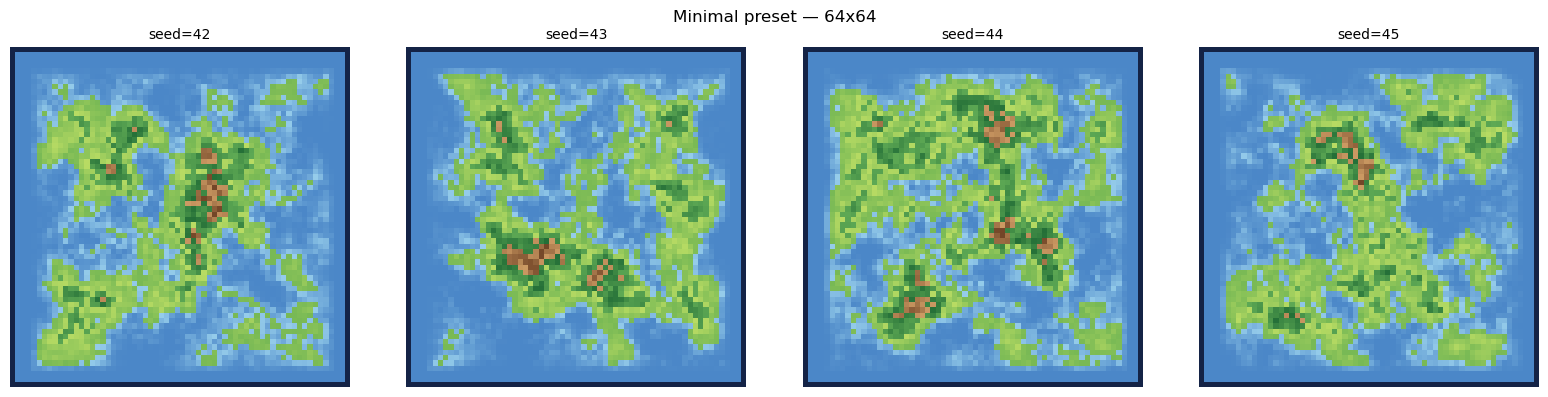

In [54]:
# Kid-game palette: warm, punchy, cartoon-like. Mountains are tan/brown
# (not snow), forest is rich emerald, grassland is a fresh lime green,
# water is a friendly cheerful blue.
CLASS_RAMPS = {
    "deadly_ocean": ((20, 35, 70),    (20, 35, 70)),     # deep navy
    "water":        ((75, 135, 200),  (150, 205, 235)),  # ocean blue → sky cyan
    "grassland":    ((120, 185, 85),  (185, 220, 100)),  # warm green → bright lime
    "forest":       ((95, 170, 85),   (35, 110, 55)),    # light leaf → deep emerald
    "mountains":    ((205, 155, 100), (115, 70, 40)),    # sandy tan → rich brown
}


def colorize_gradient(hm: torch.Tensor, terrains) -> np.ndarray:
    """Interpolate each pixel between its class's two ramp endpoints by local t."""
    hm_np = hm.cpu().numpy().astype(np.float32)
    upper = np.asarray([t_.threshold for t_ in terrains], dtype=np.float32)
    names = [t_.name for t_ in terrains]

    lo_colors = np.array([CLASS_RAMPS[n][0] for n in names], dtype=np.float32)
    hi_colors = np.array([CLASS_RAMPS[n][1] for n in names], dtype=np.float32)

    idx = np.searchsorted(upper, hm_np, side="right").clip(0, len(names) - 1)

    lower = np.empty_like(upper)
    lower[0] = min(float(hm_np.min()), upper[0]) - 1e-3
    lower[1:] = upper[:-1]

    lo = lower[idx]
    hi = upper[idx]
    t = np.clip((hm_np - lo) / np.maximum(hi - lo, 1e-6), 0.0, 1.0)

    c0 = lo_colors[idx]
    c1 = hi_colors[idx]
    out = c0 * (1.0 - t[..., None]) + c1 * t[..., None]
    return np.clip(out, 0, 255).astype(np.uint8)


fig, axes = plt.subplots(1, N_MAPS, figsize=(4 * N_MAPS, 4))
if N_MAPS == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    rgb = colorize_gradient(maps[i], MINIMAL_TERRAINS)
    ax.imshow(rgb, interpolation="nearest")
    ax.set_title(f"seed={BASE_SEED + i}", fontsize=10)
    ax.set_axis_off()
fig.suptitle(f"Minimal preset — {SIZE}x{SIZE}", fontsize=12)
plt.tight_layout()
plt.show()